<a href="https://colab.research.google.com/github/sreevathsa888/Oleti_Sree_Vathsa/blob/main/EDA_Course_Project_23BDS0143_Males_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Phase 1 - Exploratory Data Analysis Course Project

Name: Oleti Sree Vathsa
Register Number: 23BDS0143

In [ ]:

# PHASE 1 - EXPLORATORY DATA ANALYSIS
# Name : Oleti Sree Vathsa
# Reg No : 23BDS0143


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

sns.set(style="whitegrid")

In [ ]:


url = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/Males.csv"

df = pd.read_csv(url)

print("Dataset Loaded Successfully")
print()

df.head()

Dataset Loaded Successfully



,rownames,nr,year,school,exper,union,ethn,maried,health,wage,industry,occupation,residence
0,1,13,1980,14,1,no,other,no,no,1.197540,Business_and_Repair_Service,Service_Workers,north_east
1,2,13,1981,14,2,yes,other,no,no,1.853060,Personal_Service,Service_Workers,north_east
2,3,13,1982,14,3,no,other,no,no,1.344462,Business_and_Repair_Service,Service_Workers,north_east
3,4,13,1983,14,4,no,other,no,no,1.433213,Business_and_Repair_Service,Service_Workers,north_east
4,5,13,1984,14,5,no,other,no,no,1.568125,Personal_Service,"Craftsmen, Foremen_and_kindred",north_east


In [ ]:
print("Shape of Dataset :", df.shape)

print("\nColumn Names\n")
print(df.columns)

print("\nDataset Information\n")
df.info()

Shape of Dataset : (4360, 13)

Column Names

Index(['rownames', 'nr', 'year', 'school', 'exper', 'union', 'ethn', 'maried',
       'health', 'wage', 'industry', 'occupation', 'residence'],
      dtype='object')

Dataset Information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4360 entries, 0 to 4359
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   rownames    4360 non-null   int64  
 1   nr          4360 non-null   int64  
 2   year        4360 non-null   int64  
 3   school      4360 non-null   int64  
 4   exper       4360 non-null   int64  
 5   union       4360 non-null   object 
 6   ethn        4360 non-null   object 
 7   maried      4360 non-null   object 
 8   health      4360 non-null   object 
 9   wage        4360 non-null   float64
 10  industry    4360 non-null   object 
 11  occupation  4360 non-null   object 
 12  residence   3115 non-null   object 
dtypes: float64(1), int64(5), object(7)
memor

In [ ]:
print("Basic Statistical Analysis")

df.describe(include='all')

Basic Statistical Analysis


,rownames,nr,year,school,exper,union,ethn,maried,health,wage,industry,occupation,residence
count,4360.000000,4360.000000,4360.000000,4360.000000,4360.000000,4360,4360,4360,4360,4360.000000,4360,4360,3115
unique,NaN,NaN,NaN,NaN,NaN,2,3,2,2,NaN,12,9,4
top,NaN,NaN,NaN,NaN,NaN,no,other,no,no,NaN,Manufacturing,"Craftsmen, Foremen_and_kindred",south
freq,NaN,NaN,NaN,NaN,NaN,3296,3176,2446,4286,NaN,1231,934,1333
mean,2180.500000,5262.058716,1983.500000,11.766972,6.514679,NaN,NaN,NaN,NaN,1.649147,NaN,NaN,NaN
std,1258.767916,3496.149815,2.291551,1.746181,2.825873,NaN,NaN,NaN,NaN,0.532609,NaN,NaN,NaN
min,1.000000,13.000000,1980.000000,3.000000,0.000000,NaN,NaN,NaN,NaN,-3.579079,NaN,NaN,NaN
25%,1090.750000,2329.000000,1981.750000,11.000000,4.000000,NaN,NaN,NaN,NaN,1.350717,NaN,NaN,NaN
50%,2180.500000,4569.000000,1983.500000,12.000000,6.000000,NaN,NaN,NaN,NaN,1.671143,NaN,NaN,NaN
75%,3270.250000,8406.000000,1985.250000,12.000000,9.000000,NaN,NaN,NaN,NaN,1.991086,NaN,NaN,NaN


In [ ]:
print("Missing Values")

df.isnull().sum()

Missing Values


,0
rownames,0
nr,0
year,0
school,0
exper,0
union,0
ethn,0
maried,0
health,0
wage,0


In [ ]:
# Fill Numerical Missing Values

num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill Categorical Missing Values

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values handled successfully.")

df.isnull().sum()

Missing values handled successfully.


,0
rownames,0
nr,0
year,0
school,0
exper,0
union,0
ethn,0
maried,0
health,0
wage,0


In [ ]:
# Remove Duplicate Records

duplicates = df.duplicated().sum()

print("Duplicate Records :", duplicates)

df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates :", df.shape)

Duplicate Records : 0
Dataset Shape After Removing Duplicates : (4360, 13)


In [ ]:
# Encoding for Categorical Columns

encoder = LabelEncoder()

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

print("Categorical columns transformed successfully.")

df.head()

Categorical columns transformed successfully.


,rownames,nr,year,school,exper,union,ethn,maried,health,wage,industry,occupation,residence
0,1,13,1980,14,1,0,2,0,0,1.197540,1,8,0
1,2,13,1981,14,2,1,2,0,0,1.853060,7,8,0
2,3,13,1982,14,3,0,2,0,0,1.344462,1,8,0
3,4,13,1983,14,4,0,2,0,0,1.433213,1,8,0
4,5,13,1984,14,5,0,2,0,0,1.568125,7,1,0


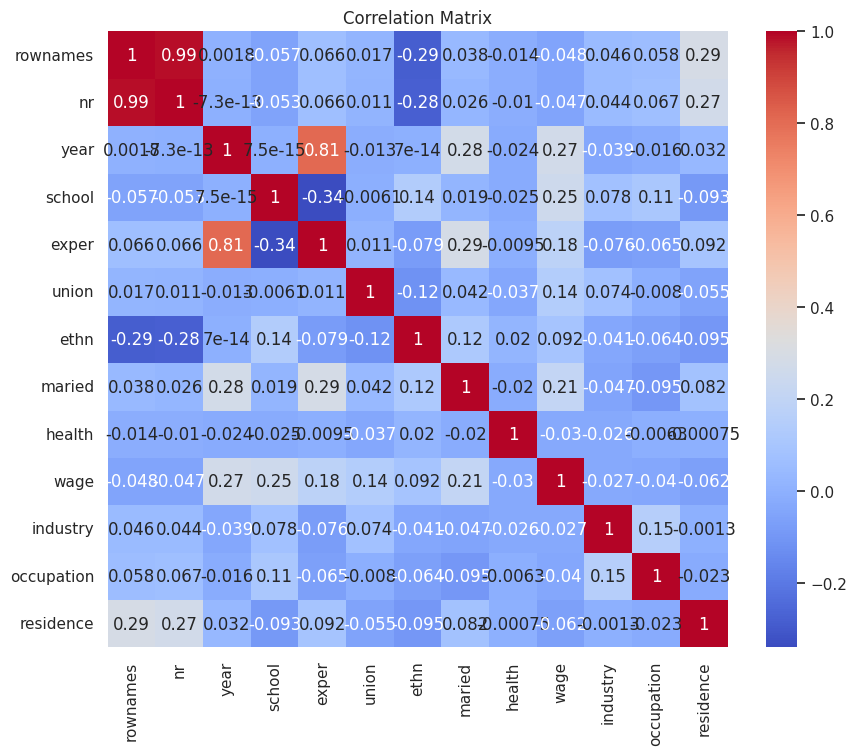

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

UNIVARIATE ANALYSIS

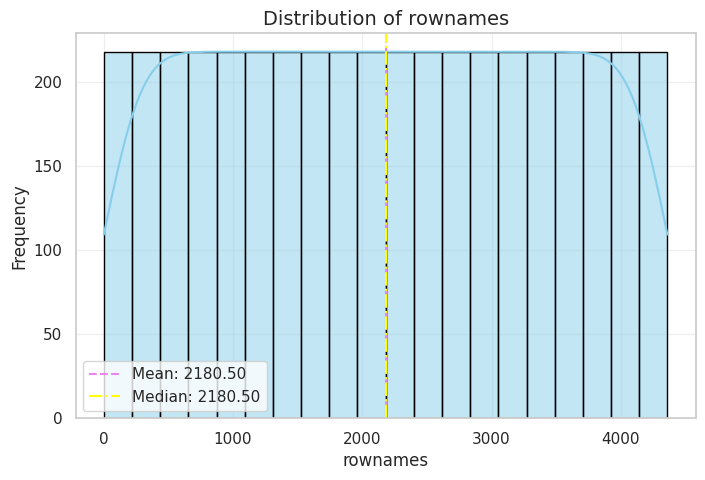

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df[num_cols[0]], bins=20, kde=True, color='skyblue', edgecolor='black')

mean_val = df[num_cols[0]].mean()
median_val = df[num_cols[0]].median()

plt.axvline(mean_val, color='violet', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='yellow', linestyle='-.', linewidth=1.5, label=f'Median: {median_val:.2f}')

plt.title(f'Distribution of {num_cols[0]}', fontsize=14)
plt.xlabel(num_cols[0], fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

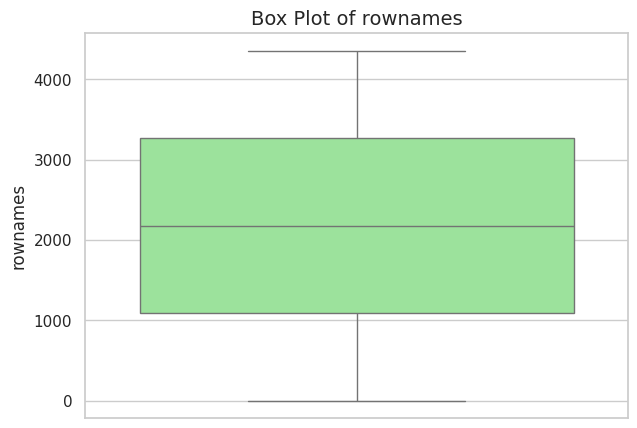

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(y=df[num_cols[0]], color='lightgreen')

plt.title(f'Box Plot of {num_cols[0]}', fontsize=14)

plt.xlabel('')

plt.ylabel(num_cols[0], fontsize=12)

plt.show()

/tmp/ipykernel_2330/1065612456.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df[categorical_columns[0]], palette='viridis')


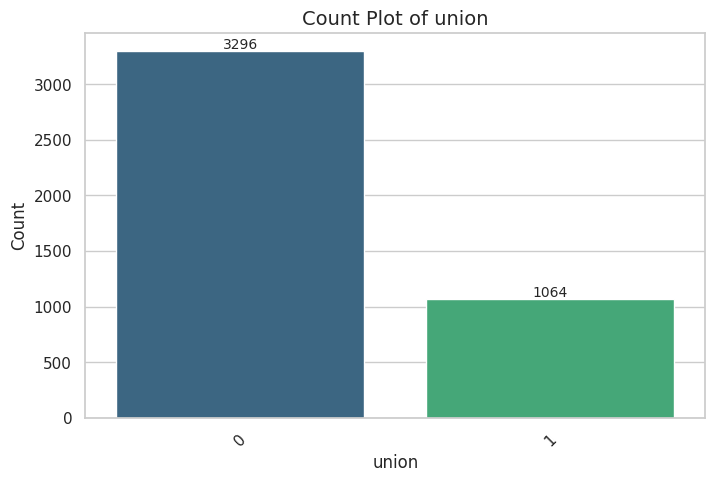

In [ ]:
plt.figure(figsize=(8,5))

ax = sns.countplot(x=df[categorical_columns[0]], palette='viridis')

for container in ax.containers:
    ax.bar_label(container, fontsize=10)

plt.title(f'Count Plot of {categorical_columns[0]}', fontsize=14)
plt.xlabel(categorical_columns[0], fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.show()

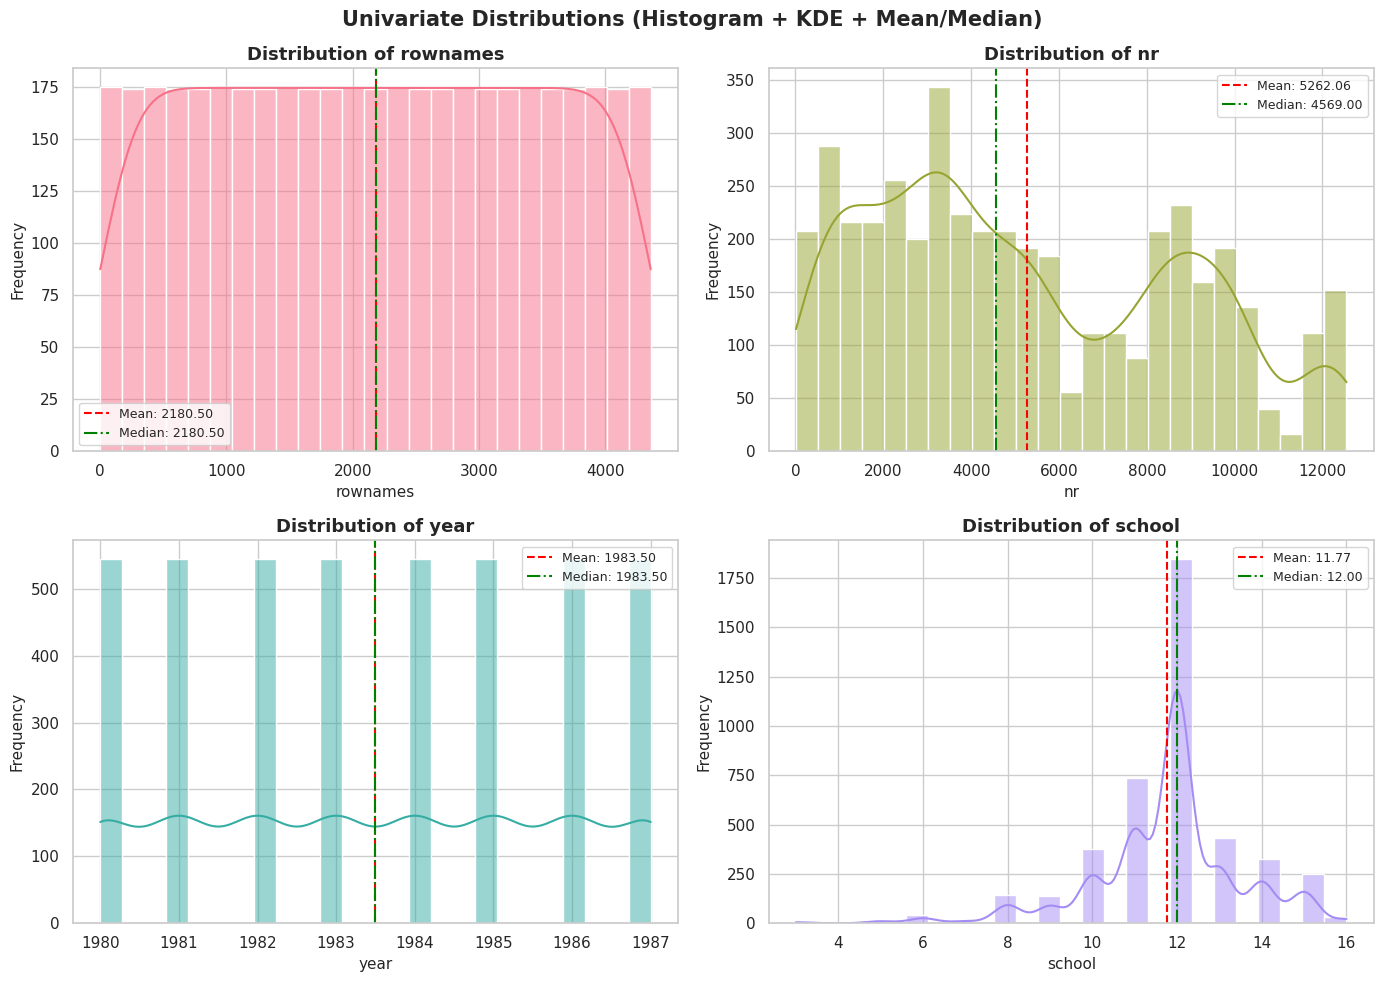

In [ ]:
cols_to_plot = num_cols[:4] if len(num_cols) >= 4 else num_cols

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.histplot(df[col], kde=True, bins=25, color=sns.color_palette("husl", 4)[i], ax=axes[i])
    mean_val = df[col].mean()
    median_val = df[col].median()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
    axes[i].axvline(median_val, color='green', linestyle='-.', linewidth=1.5, label=f'Median: {median_val:.2f}')
    axes[i].set_title(f'Distribution of {col}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=11)
    axes[i].set_ylabel('Frequency', fontsize=11)
    axes[i].legend(fontsize=9)

for j in range(len(cols_to_plot), 4):
    fig.delaxes(axes[j])

plt.suptitle("Univariate Distributions (Histogram + KDE + Mean/Median)", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Bivariate Analysis

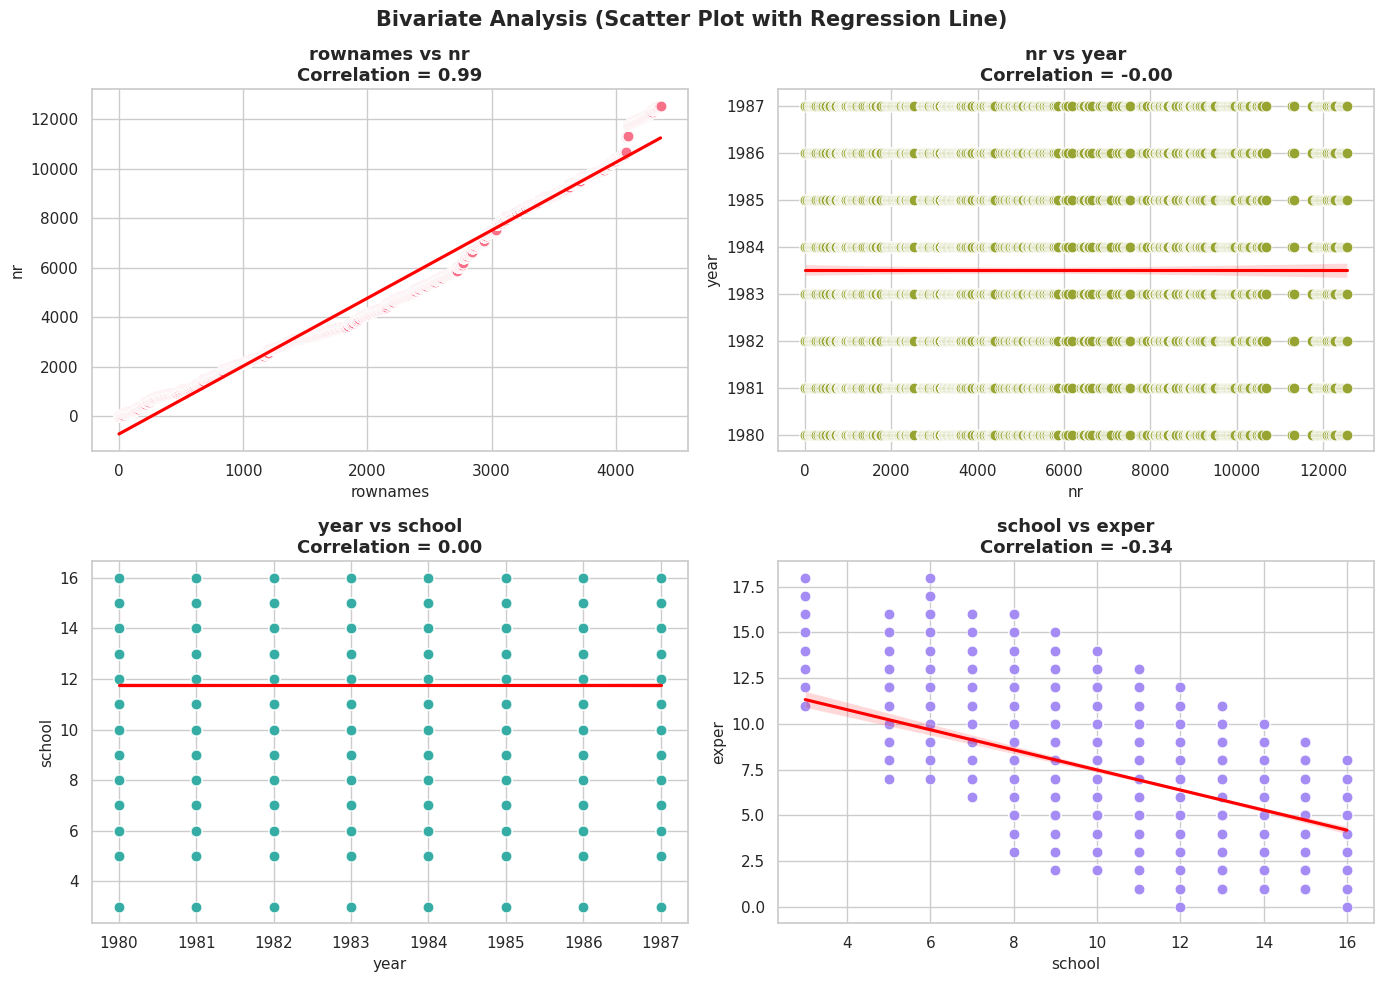

In [ ]:
num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(exclude='number').columns

pairs = [(num_cols[i], num_cols[i+1]) for i in range(min(len(num_cols)-1, 4))]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (x_col, y_col) in enumerate(pairs):

    sns.scatterplot(
        data=df,
        x=x_col,
        y=y_col,
        color=sns.color_palette("husl",4)[i],
        s=60,
        ax=axes[i]
    )

    sns.regplot(
        data=df,
        x=x_col,
        y=y_col,
        scatter=False,
        color='red',
        ax=axes[i]
    )

    corr = df[[x_col, y_col]].corr().iloc[0,1]

    axes[i].set_title(
        f'{x_col} vs {y_col}\nCorrelation = {corr:.2f}',
        fontsize=13,
        fontweight='bold'
    )

    axes[i].set_xlabel(x_col, fontsize=11)
    axes[i].set_ylabel(y_col, fontsize=11)

for j in range(len(pairs), 4):
    fig.delaxes(axes[j])

plt.suptitle("Bivariate Analysis (Scatter Plot with Regression Line)", fontsize=15, fontweight='bold')

plt.tight_layout()

plt.show()

/tmp/ipykernel_2330/3677651905.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[categorical_columns[0]], y=df[num_cols[0]], palette='pastel')


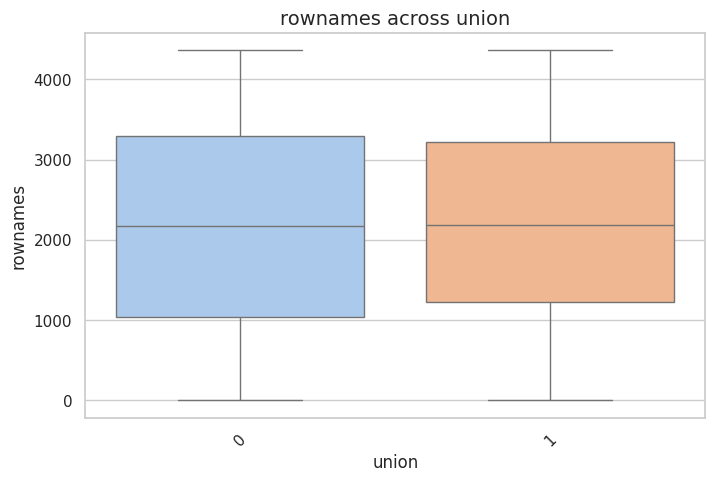

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df[categorical_columns[0]], y=df[num_cols[0]], palette='pastel')

plt.title(f'{num_cols[0]} across {categorical_columns[0]}', fontsize=14)
plt.xlabel(categorical_columns[0], fontsize=12)
plt.ylabel(num_cols[0], fontsize=12)
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_2330/2323985141.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x=df[categorical_columns[0]], y=df[num_cols[0]],
/tmp/ipykernel_2330/2323985141.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=df[categorical_columns[0]], y=df[num_cols[0]],


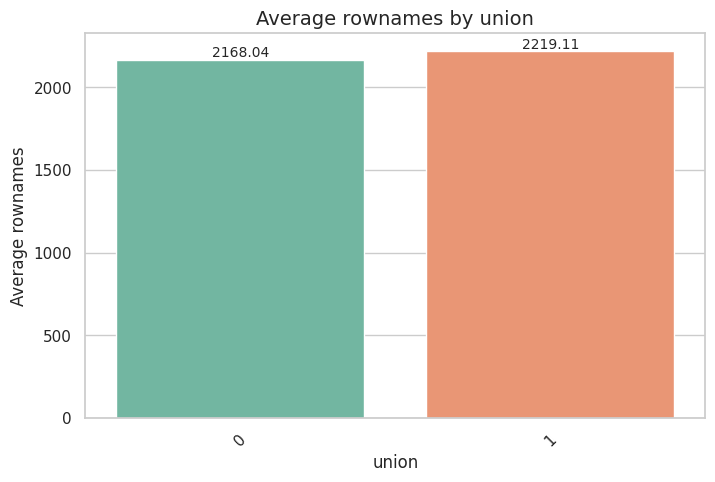

In [ ]:
plt.figure(figsize=(8,5))

ax = sns.barplot(x=df[categorical_columns[0]], y=df[num_cols[0]],
                  estimator=np.mean, palette='Set2', ci=None)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=10)

plt.title(f'Average {num_cols[0]} by {categorical_columns[0]}', fontsize=14)
plt.xlabel(categorical_columns[0], fontsize=12)
plt.ylabel(f'Average {num_cols[0]}', fontsize=12)
plt.xticks(rotation=45)
plt.show()

Multivariate Analysis

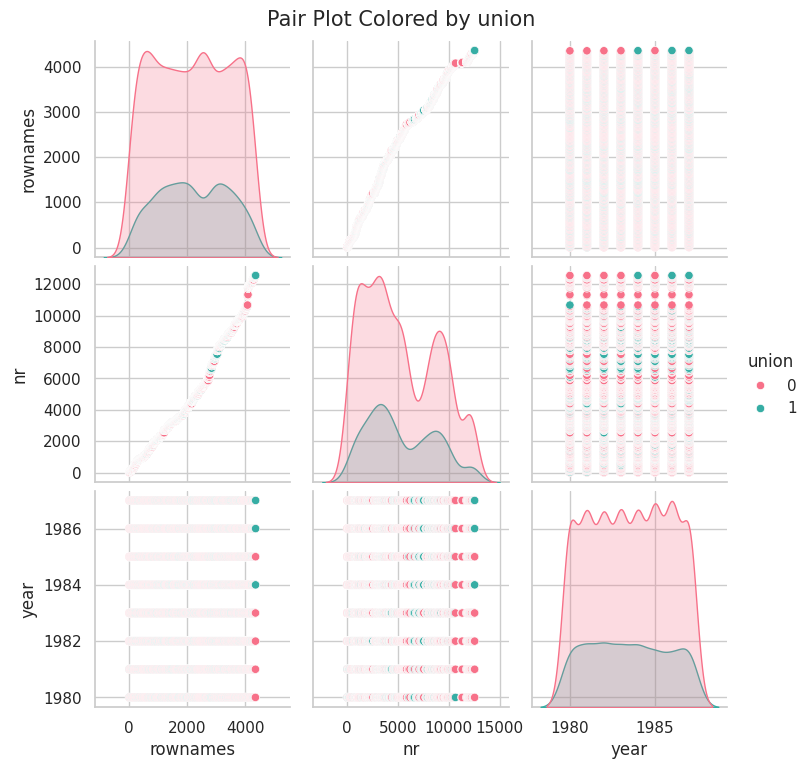

In [ ]:
sns.pairplot(df, vars=num_cols[:3], hue=categorical_columns[0], palette='husl')

plt.suptitle("Pair Plot Colored by " + categorical_columns[0], y=1.02, fontsize=15)
plt.show()

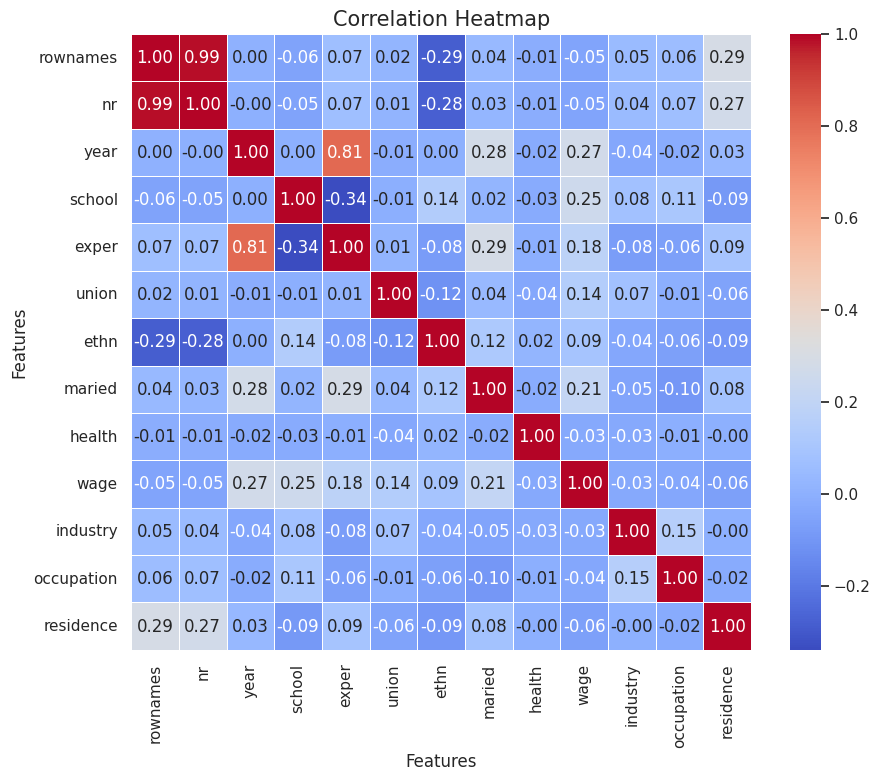

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title("Correlation Heatmap", fontsize=15)
plt.xlabel("Features", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.show()

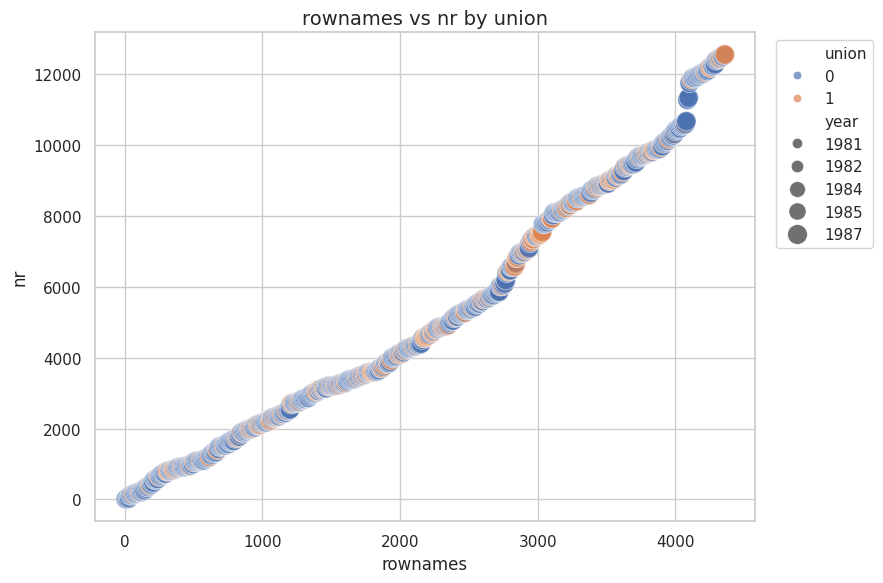

In [ ]:
plt.figure(figsize=(9,6))

sns.scatterplot(x=df[num_cols[0]], y=df[num_cols[1]],
                 hue=df[categorical_columns[0]], size=df[num_cols[2]] if len(num_cols) > 2 else None,
                 palette='deep', alpha=0.7, sizes=(30,200))

plt.title(f'{num_cols[0]} vs {num_cols[1]} by {categorical_columns[0]}', fontsize=14)
plt.xlabel(num_cols[0], fontsize=12)
plt.ylabel(num_cols[1], fontsize=12)
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

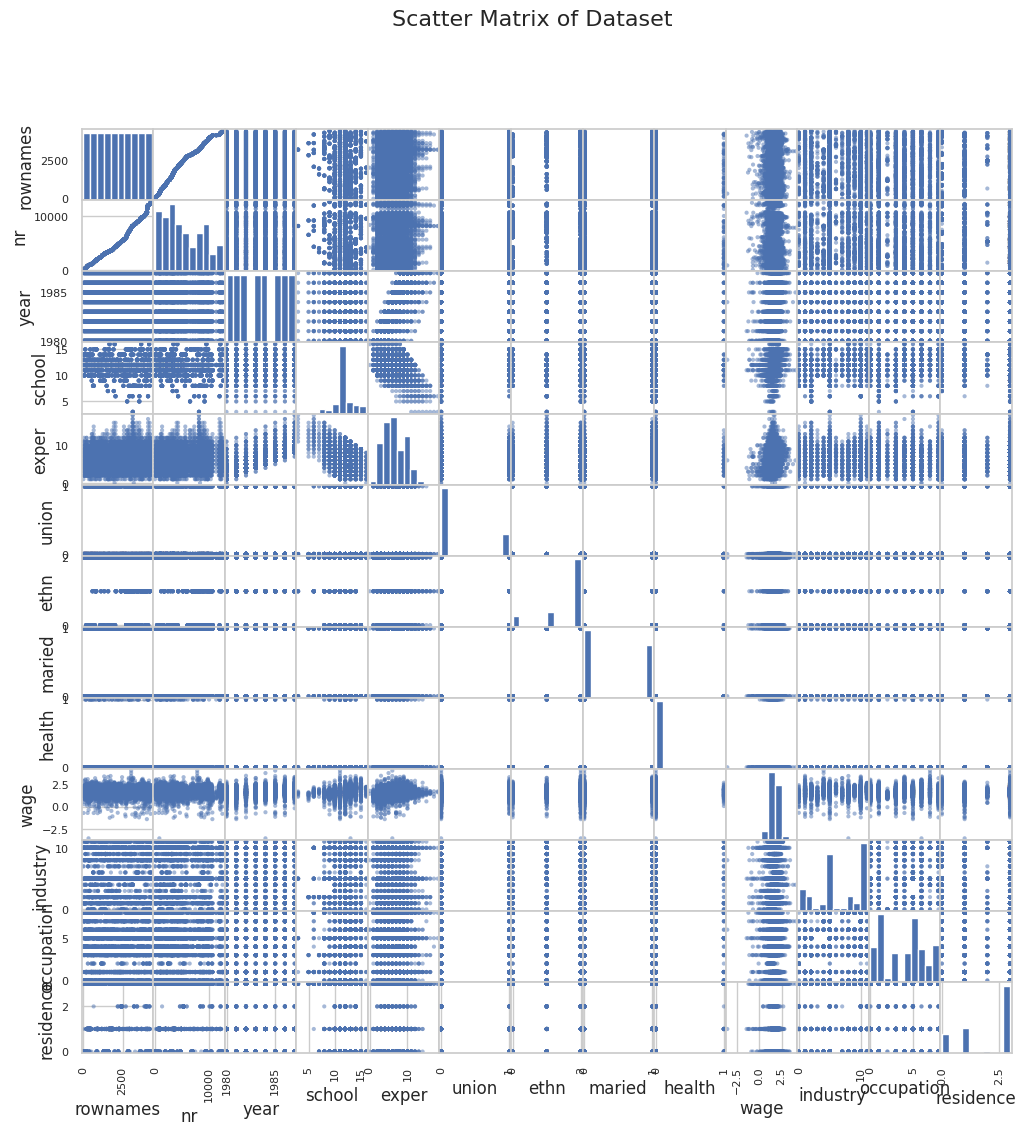

In [ ]:
pd.plotting.scatter_matrix(
    df,
    figsize=(12,12),
    diagonal='hist'
)

plt.suptitle("Scatter Matrix of Dataset", fontsize=16)

plt.show()

In [ ]:
print("EDA Phase 1 Completed Successfully")

print("""
Tasks Completed

✔ Dataset Loaded
✔ Basic Statistical Analysis
✔ Missing Value Handling
✔ Data Cleaning
✔ Data Transformation
✔ Univariate Analysis (3 Graphs)
✔ Bivariate Analysis (3 Graphs)
✔ Multivariate Analysis (3 Graphs)
""")

EDA Phase 1 Completed Successfully

Tasks Completed

✔ Dataset Loaded
✔ Basic Statistical Analysis
✔ Missing Value Handling
✔ Data Cleaning
✔ Data Transformation
✔ Univariate Analysis (3 Graphs)
✔ Bivariate Analysis (3 Graphs)
✔ Multivariate Analysis (3 Graphs)

